In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Locate cleaned dataset
if os.path.exists(os.path.join("data", "processed", "processed_data.csv")):
    PROCESSED_PATH = os.path.join("data", "processed", "processed_data.csv")
else:
    PROCESSED_PATH = os.path.join("..", "data", "processed", "processed_data.csv")

df = pd.read_csv(PROCESSED_PATH)
print(f"Loaded processed dataset shape: {df.shape}")
df.head()

Loaded processed dataset shape: (57828, 11)


,asin,name,rating,date,verified,title,body,helpfulvotes,brand,clean_review,review_length
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0,DEF,I had the Samsung A600 for awhile which is abs...,327
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0,TEXT,Due to a software issue between Nokia and Spri...,129
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0,LOVE,"This is a great, reliable phone. I also purcha...",131
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0,LOVE,"I love the phone and all, because I really did...",107
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0,GREAT,The phone has been great for every purpose it ...,128


C:\Users\iworld\AppData\Local\Temp\ipykernel_18828\2949197132.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x="brand", order=top_brands, palette="viridis")


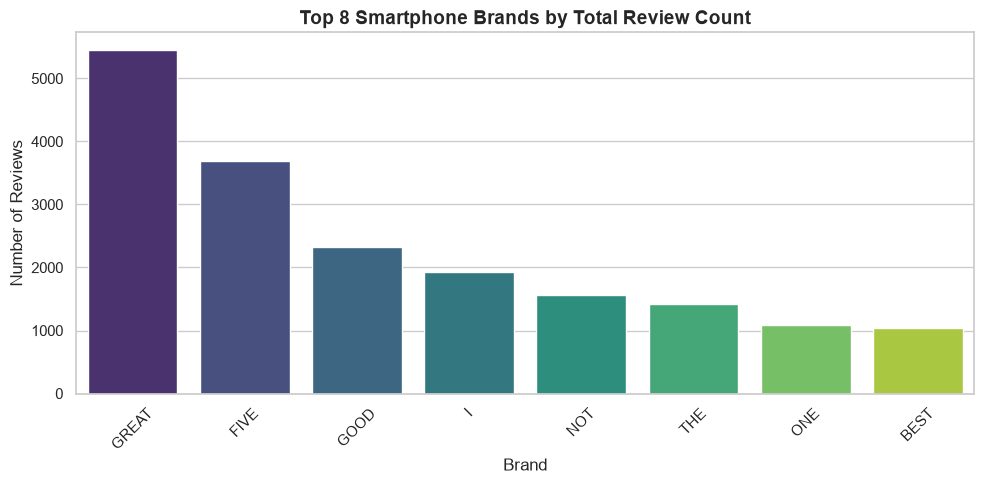

Top 8 Brands by Count:
brand
GREAT    5457
FIVE     3696
GOOD     2331
I        1930
NOT      1569
THE      1425
ONE      1093
BEST     1043
Name: count, dtype: int64


In [7]:
# Identify rating and brand columns
rating_col = next((col for col in ["rating", "ratings", "score"] if col in df.columns), None)

# Get top 8 most reviewed brands
top_brands = df["brand"].value_counts().head(8).index
df_top = df[df["brand"].isin(top_brands)].copy()

# Plot review distribution by brand
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, x="brand", order=top_brands, palette="viridis")
plt.title("Top 8 Smartphone Brands by Total Review Count", fontsize=14, fontweight="bold")
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 8 Brands by Count:")
print(df_top["brand"].value_counts())

C:\Users\iworld\AppData\Local\Temp\ipykernel_18828\2684801111.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="brand", y=rating_col, order=brand_stats["brand"], palette="mako")


--- Brand Rating Summary Statistics ---
   brand  count      mean  median       std
1   FIVE   3696  4.989177     5.0  0.187258
0   BEST   1043  4.904123     5.0  0.369692
3  GREAT   5457  4.705149     5.0  0.678885
2   GOOD   2331  4.344487     5.0  0.895956
4      I   1930  3.646632     5.0  1.626154
7    THE   1425  3.426667     4.0  1.639699
5    NOT   1569  1.915233     1.0  1.212111
6    ONE   1093  1.336688     1.0  1.078468


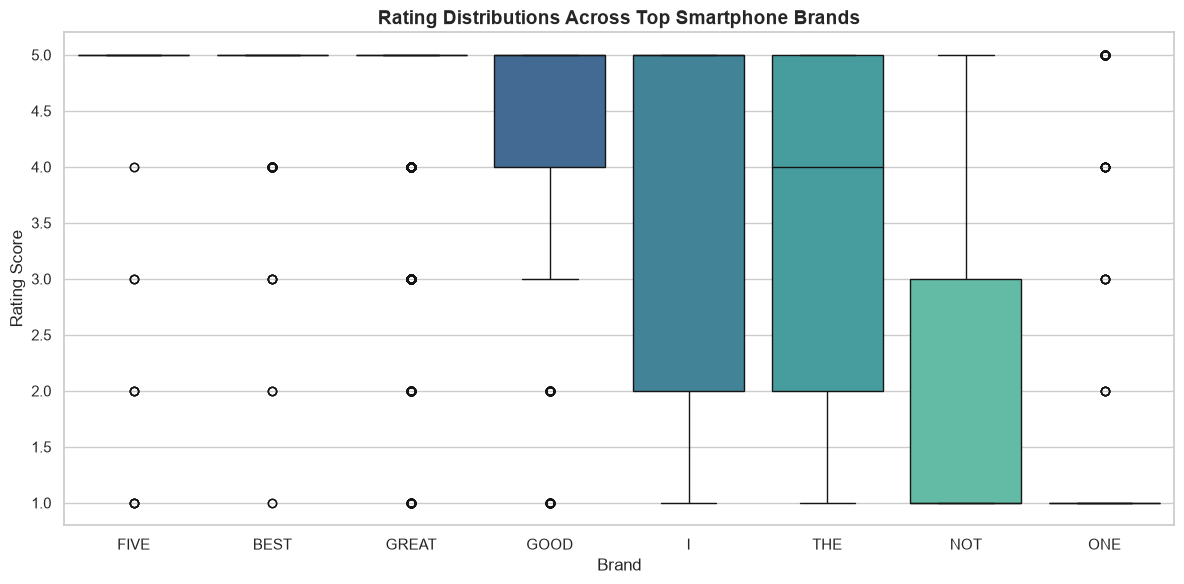

In [8]:
# Grouped rating stats per brand
brand_stats = df_top.groupby("brand")[rating_col].agg(["count", "mean", "median", "std"]).reset_index()
brand_stats = brand_stats.sort_values(by="mean", ascending=False)
print("--- Brand Rating Summary Statistics ---")
print(brand_stats)

# Boxplot of ratings per brand
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x="brand", y=rating_col, order=brand_stats["brand"], palette="mako")
plt.title("Rating Distributions Across Top Smartphone Brands", fontsize=14, fontweight="bold")
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Rating Score", fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Group ratings into lists per brand
brand_groups = [group[rating_col].values for name, group in df_top.groupby("brand")]

# Run Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(*brand_groups)

print("=== Statistical Significance Test ===")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: Reject the null hypothesis (H0).")
    print("Conclusion: There is a statistically significant difference in user ratings across different smartphone brands.")
else:
    print("\nResult: Fail to reject the null hypothesis (H0).")
    print("Conclusion: No statistically significant rating differences were detected across brands.")

=== Statistical Significance Test ===
Kruskal-Wallis H-statistic: 9134.1467
p-value: 0.0000e+00

Result: Reject the null hypothesis (H0).
Conclusion: There is a statistically significant difference in user ratings across different smartphone brands.


=== Review Length vs Rating Correlation ===
Spearman Correlation Coefficient: -0.1831
p-value: 0.0000e+00


C:\Users\iworld\AppData\Local\Temp\ipykernel_18828\3302864375.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=rating_col, y="review_length", palette="Blues_d")


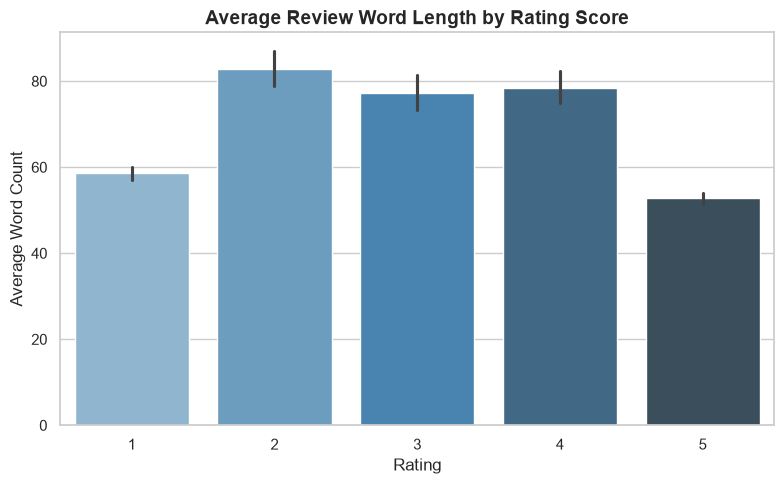

In [10]:
# Correlation between review word length and rating
corr, p_corr = stats.spearmanr(df[rating_col], df["review_length"])

print("=== Review Length vs Rating Correlation ===")
print(f"Spearman Correlation Coefficient: {corr:.4f}")
print(f"p-value: {p_corr:.4e}")

# Visualization: Average review length by rating score
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=rating_col, y="review_length", palette="Blues_d")
plt.title("Average Review Word Length by Rating Score", fontsize=14, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Average Word Count", fontsize=12)
plt.tight_layout()
plt.show()